In [2]:
import numpy as np
import matplotlib.pyplot as plt
import FEM1D

#### 1D Linear Flux

In [10]:
## NONLINEAR FLUX LAW DUMMY CASE ##
# rmk: here we have an smooth, analytic constitutive law that is differentiable by hand

def source(T, xg): # source
    return 1.0

def fluxLinSanityCheck(T_prime, T, xg):
    
    q = -T_prime # we put k = 1 in q = -kT', the fourier law
    phi_s = -1.0
    phi_T = 0.0
    
    return q, phi_s, phi_T

# since q = -T', q' = r = 1, we have -T'' = 1. use Dirichlet BC T(0) = 0, T(1) = 0. 
U_exact = lambda x: 0.5*x*(1.0-x)

U_sanity, iter_sanity, evals_sanity, time_sanity, err_sanity = FEM1D.FEM_wrapper([0.0, 1.0], 20, fluxLinSanityCheck, source, 0.0, 0.0, True,solution=U_exact)

Newton  0: ||R_eff||_2 = 2.179e-01
Newton  1: ||R_eff||_2 = 1.350e-15

FEM solution U:
[0.      0.02375 0.045   0.06375 0.08    0.09375 0.105   0.11375 0.12
 0.12375 0.125   0.12375 0.12    0.11375 0.105   0.09375 0.08    0.06375
 0.045   0.02375 0.     ]

Newton iterations: 2
Flux law evaluations: 249
Elapsed time: 0.008407210999848758
Solution error: 2.6461161338376935e-15


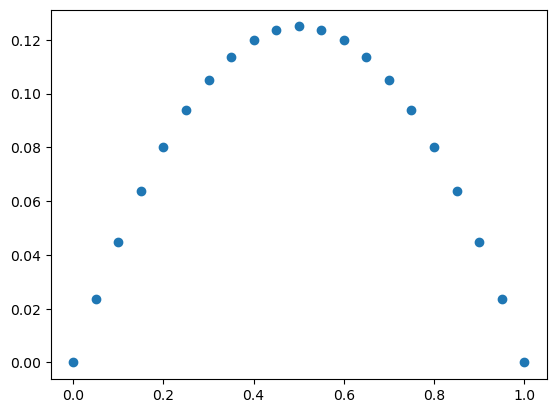

In [22]:
x = np.linspace(0.0,1.0,21)
plt.scatter(x,U_sanity)

#### 1D Nonlinear Flux w computed derivatives

In [17]:
def source(T, xg): # source
    return 1.0

def fluxNonlinExample(T_prime, T, xg):
    
    alpha = 0.25
    beta = 0.05

    q = -((1.0 + alpha * T * T) + beta * T_prime * T_prime) * T_prime
    phi_s = -(1.0 + alpha * T * T) - 3.0 * beta * T_prime * T_prime
    phi_T = -2.0 * alpha * T * T_prime

    return q, phi_s, phi_T

U_comp, iter_comp, evals_comp, time_comp, err_comp = FEM1D.FEM_wrapper([0.0, 1.0], 20, fluxNonlinExample, source, 0.0, 0.0, True)

Newton  0: ||R_eff||_2 = 2.179e-01
Newton  1: ||R_eff||_2 = 3.008e-03
Newton  2: ||R_eff||_2 = 1.536e-06
Newton  3: ||R_eff||_2 = 2.697e-13

FEM solution U:
[0.         0.0234897  0.04454669 0.06315421 0.07929947 0.09297293
 0.10416765 0.11287876 0.119103   0.12283829 0.12408351 0.12283829
 0.119103   0.11287876 0.10416765 0.09297293 0.07929947 0.06315421
 0.04454669 0.0234897  0.        ]

Newton iterations: 4
Flux law evaluations: 581
Elapsed time: 0.019873103000008996


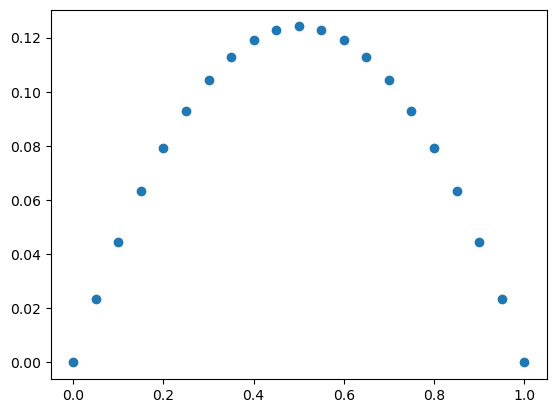

In [24]:
x = np.linspace(0.0,1.0,21)
plt.scatter(x,U_comp)

#### 1D nonlinear flux with finite differences

In [9]:
def source(T, xg): # source
    return 1.0

def flux(T_prime, T):
    alpha = 0.25
    beta = 0.05
    return -((1.0 + alpha * T * T) + beta * T_prime * T_prime) * T_prime

def fdFluxDerivatives(T_prime, T, x): 
    eta = 1e-5
    hs = eta*max(1,np.abs(T_prime))
    hT = eta*max(1,np.abs(T))

    q = flux(T_prime, T)
    phi_s = (flux(T_prime+hs,T) - flux(T_prime-hs,T)) / (2*hs) 
    phi_T = (flux(T_prime,T+hT) - flux(T_prime,T-hT)) / (2*hT)
    
    return q, phi_s, phi_T

U_fd, iter_fd, evals_fd, time_fd, err_fd = FEM1D.FEM_wrapper([0.0, 1.0], 20, fdFluxDerivatives, source, 0.0, 0.0, True)

Newton  0: ||R_eff||_2 = 2.179e-01
Newton  1: ||R_eff||_2 = 3.008e-03
Newton  2: ||R_eff||_2 = 1.536e-06
Newton  3: ||R_eff||_2 = 2.699e-13

FEM solution U:
[0.         0.0234897  0.04454669 0.06315421 0.07929947 0.09297293
 0.10416765 0.11287876 0.119103   0.12283829 0.12408351 0.12283829
 0.119103   0.11287876 0.10416765 0.09297293 0.07929947 0.06315421
 0.04454669 0.0234897  0.        ]

Newton iterations: 4
Flux law evaluations: 581
Elapsed time: 0.024462100000164355


#### 1D nonlinear flux law with automatic differentiation

In [12]:
# installation note: conda install 'jax' and 'jaxlib'
import jax
import jax.numpy as jnp

In [13]:
def source(T, xg): # source
    return 1.0

def flux(T_prime, T):
    alpha = 0.25
    beta = 0.05
    return -((1.0 + alpha * T * T) + beta * T_prime * T_prime) * T_prime

# automatic differentiation to obtain partials from given flux law
fgrad = jax.grad(flux, argnums=(0,1))

def autoFluxDerivatives(T_prime, T, x): 
    # actual derivatives
    # alpha = 0.25
    # beta = 0.05
    # phi_s_real = -(1.0 + alpha * T * T) - 3.0 * beta * T_prime * T_prime
    # phi_T_real = -2.0 * alpha * T * T_prime

    # automatic differentiation routine 
    q = flux(T_prime, T)
    T_prime_arr = jnp.array(T_prime)
    T_arr = jnp.array(T)
    phi_s_auto, phi_T_auto = fgrad(T_prime_arr,T_arr)

    # # check differences
    # print(f"real partials: {phi_s_real}, {phi_s_auto}")
    # print(f"auto partials: {phi_s_auto}, {phi_T_auto}")
    # phi_s_err = np.abs(phi_s_real - phi_s_auto) / np.abs(phi_s_real)
    # phi_T_err = np.abs(phi_T_real - phi_T_auto) / np.abs(phi_T_real)
    # print(f"error: {phi_s_err}, {phi_T_err}")
    
    return q, phi_s_auto, phi_T_auto

U_auto, iter_auto, evals_auto, time_auto, err_auto = FEM1D.FEM_wrapper([0.0, 1.0], 20, autoFluxDerivatives, source, 0.0, 0.0, True)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Newton  0: ||R_eff||_2 = 2.179e-01
Newton  1: ||R_eff||_2 = 3.008e-03
Newton  2: ||R_eff||_2 = 1.536e-06
Newton  3: ||R_eff||_2 = 7.268e-13

FEM solution U:
[0.         0.0234897  0.04454669 0.06315421 0.07929947 0.09297293
 0.10416765 0.11287876 0.119103   0.12283829 0.12408351 0.12283829
 0.119103   0.11287876 0.10416765 0.09297293 0.07929947 0.06315421
 0.04454669 0.0234897  0.        ]

Newton iterations: 4
Flux law evaluations: 581
Elapsed time: 4.208784621000177


#### Results

| Flux law | Derivative routine | \|\|R\|\| | Newton iterations | Flux law evaluations | Elapsed time |
| --- | --- | --- | --- | --- | --- | 
| Linear | Pre-computed | 1.35E-15 | 2 | 249 | 0.008407211 |
| Nonlinear | Pre-computed | 2.70E-13 | 4 | 581 | 0.01987 | 
| Nonlinear | Finite differences | 2.70E-13 | 4 | 581 | 0.02446 | 
| Nonlinear | Automatic differentiation | 7.27E-13 | 4 | 581 | 4.20878 |